In [19]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy import optimize
import random
import sys
import scipy.io
from scipy.fftpack import fft, ifft
from sklearn.model_selection import KFold
import pandas as pd
from scipy.optimize import dual_annealing
#import seaborn as sns
%matplotlib inline


In [20]:
# Grid Search: Finds the best starting "seeds."

# K-Fold: Proves the seeds/method work reliably on different data slices.

# Final Optimization: Polishes those seeds into the final K and C values.

# Evaluation: The final "Final Exam" to see how those values perform on unseen data.

In [21]:
#SENSOR_DATA_TOTAL = 'Amplitude' # 'Time' or 'Amplitude' or 'Vibration'
#SIMILARITY_METHOD = 'MAAPE'  # 'correlation', 'MSE'  .. ........  To test both and find references
#INTERPOLATION_METHOD = 'quadratic'  # 'linear', 'quadratic'   ........... is it better to be linear or qudaratic?
#SIMILARITY_THRESHOLD = 10      #...............######################## I have to motivate this value or find it in statistic "significant"


SENSOR_DATA_TOTAL = 'humi'  # 'humi' or 'temp'
SIMILARITY_METHOD = 'MAAPE'  # 'correlation', 'MSE'  .. ........  To test both and find references # CORRELATION NOT ADDED TO THE LOOP
# Correlation: higher means better, MAAPE lower means better
INTERPOLATION_METHOD = 'linear'  # 'linear', 'quadratic'   ........... is it better to be linear or qudaratic?
SIMILARITY_THRESHOLD = 2

In [22]:
#ENSOR_DATA_PD = pd.read_csv('../data/generated_values5.txt', delim_whitespace = True)
SENSOR_DATA_PD = pd.read_csv('../data/HumiAndTemp12mins.txt', delim_whitespace = True)
print(len(SENSOR_DATA_PD))
SENSOR_DATA_PD.head(10)

371


/var/folders/5s/hwctbd0x2wv8hfcsb313f1h00000gn/T/ipykernel_20381/1511983964.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  SENSOR_DATA_PD = pd.read_csv('../data/HumiAndTemp12mins.txt', delim_whitespace = True)


,Humi,Temp
0,41.7,24.4
1,41.7,24.4
2,41.7,24.4
3,41.7,24.4
4,41.8,24.4
5,41.8,24.3
6,42.3,24.3
7,42.2,24.3
8,42.2,24.3
9,42.1,24.3


In [23]:
SENSOR_DATA_TOTAL = np.array(SENSOR_DATA_PD.Humi)
#SENSOR_DATA_TOTAL = np.resize(SENSOR_DATA_TOTAL, 500)
SENSOR_DATA_TOTAL = np.resize(SENSOR_DATA_TOTAL, 371)

# 60/40 SPLIT
split_point = round(len(SENSOR_DATA_TOTAL) * 0.6)

# First 60% for training
SENSOR_DATA_TRAIN = SENSOR_DATA_TOTAL[split_point:]
# Last 40% for testing
SENSOR_DATA_TEST = SENSOR_DATA_TOTAL[:split_point]

print(f'Total: {len(SENSOR_DATA_TOTAL)}')
print(f'Training (60%): {len(SENSOR_DATA_TRAIN)}')
print(f'Testing (40%): {len(SENSOR_DATA_TEST)}')

Total: 371
Training (60%): 148
Testing (40%): 223


In [24]:
def interp_linear(x, y): # Find new data points between known(measured) data points using straight line
    '''Linear interpolation'''
    res = [] # result lst 
    for i in range(1, len(x)):
        slope = (y[i] - y[i - 1]) / (x[i] - x[i - 1])
        l = y[i] - slope * x[i] # y= m*x + b, m is the slope, b refers to l
        res.extend([slope * x_betw + l for x_betw in range(x[i - 1], x[i])]) 
    res.append(y[-1])  # include last data set for example (1, 4) doesn't include 4, only 1, 2, 3
    return np.array(res)  # x is the time, y is the sensor reading

In [25]:
def interp_quadratic(x, y): # Find new data points between known(measured) data points using curved lines
    '''Quadratic interpolation'''
    if len(x) == 2:
        print('Use linear interpolation instead of polinomial when number of samples equals 2')
        return interp_linear(x, y)
    a = ((y[2] - y[0]) / ((x[2] - x[0]) * (x[2] - x[1])) - 
             (y[1] - y[0]) / ((x[1] - x[0]) * (x[2] - x[1])))
    b = (a * (x[0] ** 2 - x[1] ** 2) + y[1] - y[0]) / (x[1] - x[0])
    c = y[0] - a * x[0] ** 2 - b * x[0]
    res = [a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[0], x[2])]
    for i in range(1, len(x) - 2):
        a = ((y[i + 2] - y[i]) / ((x[i + 2] - x[i]) * (x[i + 2] - x[i + 1])) - 
             (y[i + 1] - y[i]) / ((x[i + 1] - x[i]) * (x[i + 2] - x[i + 1])))
        b = (a * (x[i] ** 2 - x[i + 1] ** 2) + y[i + 1] - y[i]) / (x[i + 1] - x[i])
        c = y[i] - a * x[i] ** 2 - b * x[i]
        res.extend([a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[i + 1], x[i + 2])])  
    res.append(y[-1])
    return np.array(res)

In [26]:
def cor(f, g): # calculate cosine simularity, how two sets of data moves together (both tend to go up or down, overal pattern)
    '''Correlation function that you provide'''
    return 100 * np.dot(f, g) / (math.sqrt(np.dot(f, f)) * math.sqrt(np.dot(g, g))) # math formula: 100 * dot product of f and g / squre root of f * squre root of g

In [27]:
#chekc this article for MAAPE "A new metric of absolute percentage error for intermittent demand forecasts"
def MAAPE(f,g): # evaluate how accurate the forcast model's predictions are, f and g are 2 lists of numbers comparing (to find the difference)
    EPSILON = 1e-10
    return np.mean(np.arctan(np.abs((f - g) / (f + EPSILON)))) * 100 
# compare f and g by find the difference, arctan to find the angle of difference, (f + EPSILON) actual measured value + minor buffer (don't divide by 0)
     

In [28]:
other = (SENSOR_DATA_TRAIN, INTERPOLATION_METHOD, SIMILARITY_METHOD, SIMILARITY_THRESHOLD) # ANALYSIS CONFIG
# total_data, linear/ quadratic, MAPPE, 2

In [ ]:
def measure(params, *other):                                                        
    '''Returns the number of measurements for certain K and C'''         #.........  params means k and c same number?
    data, interpolation, error, min_sim = other         #...........#############......what is this? how to use it?
    K, C = params                                      #...........#############
    prev_meas = 0
    new_meas = max(1, int(round(K)))
    measurements = []
    days = [] # track the passage of time or index
    while new_meas < len(data): # MORE DATA to process
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas) #prev_meas and new_meas are used as an index (days)
        measurements.append(data[prev_meas]) # collect all readings, actual value we measure each time, for example humidity 41.7                           
        days.append(prev_meas)                                             
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope))) # shifting foward: how far in the data to take the next measurements 
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days) # total number of measurements
    if prev_meas != len(data) - 1:  # to include the last measurement, in case the last point from DSRA is not the last point of the oriognal data (to include the last measurements  even it is no considered)
        measurements.append(data[-1])
        days.append(len(data) - 1)
        
    if interpolation == 'linear':
        interp_sampl = interp_linear(days, measurements)
    else:
        interp_sampl = interp_quadratic(days, measurements)
    
    if error == 'correlation':
        similarity = cor(data, interp_sampl)
    else:
        similarity = MAAPE(data, interp_sampl)
        
        # IF WE USE ERROR = correlation THEN "similarity <= min_sim" this has to be adjusted to the opposite IN ALL OF THE CODES
    
    # only if meet threshold similarity <= 2%, reutrn number of mesuarements else, else return total data length, fall back to suggest have more data to calcualte
    return num_of_meas if similarity <= min_sim else len(SENSOR_DATA_TEST)  #.... to return len of data (i.e. 780) incase less than 99.97, is that correct?
# all or nothing penalty

In [30]:
def plot2d(data, range_k, range_c, min_sim=SIMILARITY_THRESHOLD, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots the graph of the dependence the number of measurements on K and C'''  # show dfferent cobinmations of k and c
    z = [] # number of measurements                                                                        #elaborate on the figure
    x = [] # k 
    y = []  # c
    for k in range_k: # testing all k and c pairs
        for c in range_c:
            
            prev_meas = 0 # similar as measure method
            new_meas = max(1, int(round(k)))
            measurements = []
            days = []
            while new_meas < len(data):
                slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
                measurements.append(data[prev_meas])
                days.append(prev_meas)
                prev_meas, new_meas = new_meas, new_meas + max(1, int(round(k - c * slope))) # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
            measurements.append(data[prev_meas])
            days.append(prev_meas)
            num_of_meas = len(days)
            
            if prev_meas != len(data) - 1:                     # to onclude the last measurement, even it is no considered
                measurements.append(data[-1])
                days.append(len(data) - 1)

            if interpolation == 'linear':
                interp_sampl = interp_linear(days, measurements)
            else:
                interp_sampl = interp_quadratic(days, measurements)
            
            similarity = MAAPE(data, interp_sampl) # set to MAAPE by default, correlation not included
            
            if similarity <= min_sim: # if similar is good, add result to list
                z.append(len(days)) # number of measurements
                x.append(k)
                y.append(c)
    minz = min(z) # min masurements: collect as less data points as possible
    opti = []
    for j in range (len(z)):
        if minz == z[j]: # if find the least measurement
            opti.append(z[j])  # loop through and add all the values of x, y, z to the optimal result lst
            opti.append(x[j])
            opti.append(y[j])
            break

    return opti

In [ ]:
def PLOT(data, K, C, original_signal=True, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots groundtruth and measured with optimized sampling sensor signal''' # only shows the final result
    prev_meas = 0
    new_meas = max(1, int(round(K))) # next measurement: should always be bigger to move forward, not to stuck in a loop
    measurements = [] # each measured value
    days = [] # index of test data
    while new_meas < len(data):
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
        measurements.append(data[prev_meas])
        days.append(prev_meas)
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope)))  # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days)
    
    if prev_meas != len(data) - 1: # include the last value
        measurements.append(data[-1])
        days.append(len(data) - 1)
    
    if interpolation == 'linear':
        plotList = interp_linear(days, measurements)
    else:
        plotList = interp_quadratic(days, measurements)
    
    if error == 'correlation':
        similarity = cor(data, plotList)
    else:
        similarity = MAAPE(data, plotList)

    # Fixed line:
    sampling_reduced = abs((round(len(days)/len(data), 2) * 100) - 100) # percentage of amount of measured data / total data
    
    return similarity, plotList, measurements, days, sampling_reduced

In [32]:
def reconstruction(data, K, C):  # make the graph smoother
    current_TBM = 42 # start value?
    prev_TBM = 1
    reconstructed = []
    for i in range (len(data)):
        if i == 0: # 1 item
            current_TBM = 1 # shifting to next iteration
            prev_TBM = current_TBM
        else :
            current_TBM = max(1, K - abs(C * (data[i] - data[i - 1]) / prev_TBM)) # apply tbm formula, max makes sure the new tbm is at least 1, don't get stuck

            prev_TBM = current_TBM
            current_TBM = round(current_TBM) # need whole number
            nb_values = current_TBM // 1 # how many new number of values need to be added, to fill in real ones to see the trend
            # //rounds down and remove decimal parts
            
            diff = data[i] - data[i - 1] # difference bwt 2 real values

            if diff == 0: # constructed data is the same
                for _ in range (1, nb_values):
                    reconstructed.append(data[i])
            else : 
                interv = diff / (nb_values) # interval: step size between each value (even transition)
                for k in range (1, nb_values):
                    reconstructed.append(data[i - 1] + k * interv) # append new points, which = old point + slope*interval
        
        reconstructed.append(data[i])

    return reconstructed

In [33]:
def my_resize(reconstruct, original_size): # make sure reconstrucced data is exactly the right size
    
    diff = len(reconstruct) - original_size # how far is from the original size
    # If the differencce is smaller, create new data points to fill in the gaps between new data points(keep the length)
    if diff <= 0 and diff > -500 : # It is minus becauese reconstruct data is shorter
        for _ in range (-diff) : 
            reconstruct.append(reconstruct[-1])
        return reconstruct # a lst of data points
    #  If the differencce is too big, weigh fewer points, result gonna be bad
    elif diff >= 500 or diff < -500: #   SUSPICIOUS RANGE!!!!!! what if data size is much bigger, shall we count by percentage out of data points
        print("Resize will not be precise, try to change the error threshold.")
        return reconstruct
    return np.resize(reconstruct, original_size) # orginal size is passed as para (total data points)??

# DOES IT FEEL the gap? TEST!
# PUT IT ASide taht can be called and used when neeeded

In [34]:
import time

#please find your bounds

start_time = time.perf_counter()  # Record the starting time
#please find your bounds

# These arrays will contain the important values of the cross validation
cross_valid_train = []


# Initial/Default values of the ranges
rangeK = 0, 30, 2
rangeC = 0, 450, 10

# Just for the pretty print
test_nb = 0

# Has to be set as it is in the while condition
cz = 10 

# Find in call plot2d to find optimak k and c, shrink the range, 
#Understand how this works: what it does to find the best range, what does it do to find optional k and c, where the cross validation is implemented and what does it do 
while cz > 1: # number of measuerment >1 ,

    kx, ky, kz = rangeK
    cx, cy, cz = rangeC

    # call the plot2d and test which k and c are the best
    optimal_values = plot2d(SENSOR_DATA_TRAIN, range(kx, ky, kz), range(cx, cy, cz)) 

    # find the best parameters and add to lst ( optimal_values[1]represents K and  optimal_values[2]] represents C )
    cross_valid_train.append([test_nb, optimal_values[1], optimal_values[2]])  # for training

    # set k, c parameters, (kx, ky, kz), (cx, cy, cz), (optimal kx + kx / ) 2, move both above and below that point
    # Why optimal_values[1] + kx) / 2, what does it do
    kx, ky, kz = round((optimal_values[1] + kx) / 2) - 4, round((optimal_values[1] + ky)) + 4, max(1, round(kz / 2)) # divide search step by 2
    cx, cy, cz = round((optimal_values[2] + cx) / 2) - 4, round((optimal_values[2] + cy)) + 4, max(1, round(cz / 2))

    # store k and c range, increase no. measurements
    rangeK = kx, ky, kz
    rangeC = cx, cy, cz
    test_nb += 1 

# Grid search complete. Now evaluate candidates with KFold before optimization.

In [35]:
other = (SENSOR_DATA_TRAIN, INTERPOLATION_METHOD, SIMILARITY_METHOD, SIMILARITY_THRESHOLD) # ANALYSIS CONFIG

Fold 1 Best: K=2, C=0, Error=1.6246
Fold 2 Best: K=4, C=1, Error=0.8205

Averaged Starting Point: K=3.0000, C=0.5000, Avg Error=1.2225
Threshold met. Proceeding to Dual Annealing optimization...
Optimization Complete: Final K=4.481282, Final C=0.450393
---FINAL RESULTS ON Validation DATA---
Number of points in Test Set: 223
Number of points kept: 65
MAAPE Error: 2.710254418332554%
Sampling Reduction: 70.85201793721974%


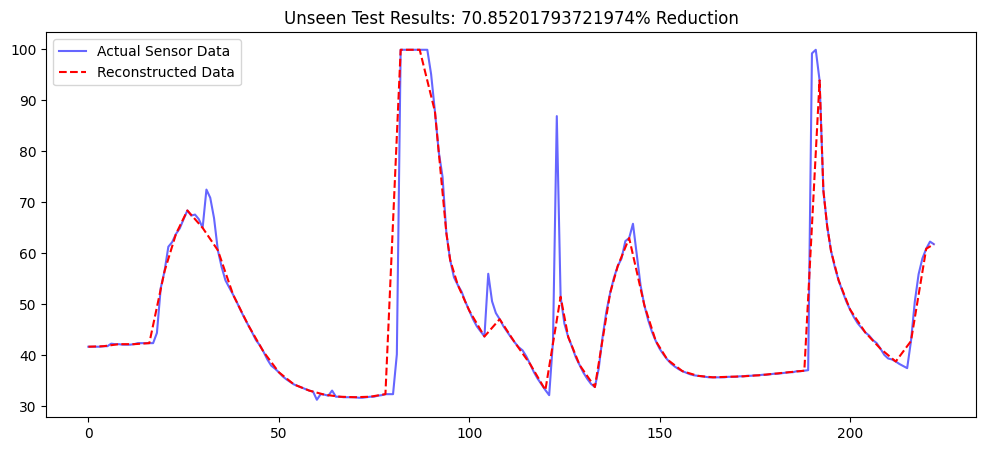

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
from scipy.optimize import dual_annealing

# 2-Fold Cross-Validation 
kfold = KFold(n_splits=2)  
fold_best_ks = []
fold_best_cs = []
fold_errors_summary = []

# Iterate through the folds first to find the best local parameters
for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(SENSOR_DATA_TRAIN)): # run loop twice, enumerate(idx of loop, value at idx)
    candidate_errors = [] # actual error values
    
    # Check every candidate from grid search against this fold
    for i in range(len(cross_valid_train)):
        tmp_k, tmp_c = cross_valid_train[i][1], cross_valid_train[i][2] # [i][1], i is row, 1 is the column
        
        # Test on the validation slice of the training data
        error_val, _, _, _, _ = PLOT(SENSOR_DATA_TRAIN[val_idx], tmp_k, tmp_c)
        plt.close()
        candidate_errors.append(error_val)
    
    # Find the best candidate for this specific fold
    best_fold_idx = np.argmin(candidate_errors) # index of the lowest error
    best_k_fold = cross_valid_train[best_fold_idx][1]
    best_c_fold = cross_valid_train[best_fold_idx][2]
    
    fold_best_ks.append(best_k_fold)
    fold_best_cs.append(best_c_fold)
    fold_errors_summary.append(np.min(candidate_errors))  # best error values 
    
    print(f"Fold {fold_idx+1} Best: K={best_k_fold}, C={best_c_fold}, Error={np.min(candidate_errors):.4f}")

# Averaging k and c from both folds for stability
avg_k = np.mean(fold_best_ks) # average k
avg_c = np.mean(fold_best_cs) # average c
avg_best_error = np.mean(fold_errors_summary)


print(f"\nAveraged Starting Point: K={avg_k:.4f}, C={avg_c:.4f}, Avg Error={avg_best_error:.4f}")

#  Dual annealing for laser focus
if avg_best_error <= SIMILARITY_THRESHOLD: # similarity <=2%
    print("Threshold met. Proceeding to Dual Annealing optimization...")
    
    # Define the search area around averaged starting point
    bounds = [(avg_k - 2, avg_k + 2), (avg_c - 2, avg_c + 2)]
    
    '''def objective(params): # find low error rate and less sampling points, contribute to better result
        k_val, c_val = params
        error, _, _, days, _ = PLOT(SENSOR_DATA_TRAIN, k_val, c_val) # days refer to specific time point or idx of the sample point
        plt.close()
        
        score = error + (len(days) / len(SENSOR_DATA_TRAIN)) * 10 # (len(days) / len(SENSOR_DATA_TRAIN)) * 10 -> low sampling points good
        return score # low score pass to dual_annealing method '''
    # Improved Objective method
    def objective(params):
        k_val, c_val = params
        # PLOT already calculates the chosen similarity metric internally
        error, _, _, days, _ = PLOT(SENSOR_DATA_TRAIN, k_val, c_val)
        plt.close()
    
        # If using Correlation, we must minimize (100 - correlation)
        if SIMILARITY_METHOD == 'correlation':
            score = (100 - error) + (len(days) / len(SENSOR_DATA_TRAIN)) * 10
        else:
            # For MAAPE, we just minimize the error directly
            score = error + (len(days) / len(SENSOR_DATA_TRAIN)) * 10
        
        return score

    # Run Dual Annealing starting from our averaged point (x0)
    result = dual_annealing(objective, bounds, x0=[avg_k, avg_c])
    # result = dual_annealing(measure, bounds, args=other, x0=[avg_k, avg_c])
    # 1. result = dual_annealing(measure, bounds, args=other, x0=[avg_k, avg_c], maxiter=900) # judge by passsing in differen param including objective, find lowest value, closer to the solution
    # 2. result = dual_annealing(measure, bounds, args=other, maxiter=900)
    
    final_k, final_c = result.x
    print(f"Optimization Complete: Final K={final_k:.6f}, Final C={final_c:.6f}")
else:
    print(f"Threshold not met. Using averaged candidates directly.")
    final_k, final_c = avg_k, avg_c

# Run the reconstruction on unseen test set
final_similarity, final_plot, final_meas, final_days, _ = PLOT(SENSOR_DATA_TEST, final_k, final_c)

# Points actually saved
sample_reduced = len(SENSOR_DATA_TEST) - len(final_days) # testing data length - reconstructed data length
reduction_percentage = (sample_reduced / len(SENSOR_DATA_TEST)) * 100

print(f"---FINAL RESULTS ON Validation DATA---")
print(f"Number of points in Test Set: {len(SENSOR_DATA_TEST)}")
print(f"Number of points kept: {len(final_days)}")
print(f"MAAPE Error: {final_similarity}%")
print(f"Sampling Reduction: {reduction_percentage}%")

# Plot to see the reconstruction
plt.figure(figsize=(12,5))
plt.plot(SENSOR_DATA_TEST, label="Actual Sensor Data", color='blue', alpha=0.6)
plt.plot(final_plot, label="Reconstructed Data", color='red', linestyle="--")
plt.title(f"Unseen Test Results: {reduction_percentage}% Reduction")
plt.legend()
plt.show()